# Generation and post-analysis in a real dataset 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tableone import TableOne
import torch
from sksurv.nonparametric import kaplan_meier_estimator
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization, metrics

module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

from synthcity.metrics.plots import plot_tsne
from synthcity.metrics.eval import Metrics
from synthcity.metrics.scores import ScoreEvaluator
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.utils.reproducibility import clear_cache, enable_reproducible_results

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [2]:
dataset_name = "ACTG320"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
miss_file = ""
true_miss_file = None

### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [3]:
control_fnames = ['time', 'censor'] + pd.read_csv(feat_types_file_control)["name"].to_list()[1:]
control = pd.read_csv(data_file_control, header=None, names=control_fnames)
print(control.head())

   time  censor  strat2  sex  raceth  ivdrug  karnof    cd4  priorzdv  age
0   189       0       1    0       1       0     100  169.0      39.0   34
1   287       0       1    1       2       0      90  149.5      15.0   34
2   199       0       1    0       1       0      90   46.0      53.0   48
3   270       0       1    0       2       0     100   54.5       6.0   51
4   276       0       1    0       1       0     100   95.0       7.0   34


In [4]:
# Load and transform control data
data_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _ = data_processing.read_data(data_file_control, 
                                                                                                             feat_types_file_control, 
                                                                                                             miss_file, true_miss_file)

In [5]:
# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _, dict_cat_map_control = data_processing.read_data(data_file_control, feat_types_file_control, miss_file, true_miss_file,
                                                                                                                                         return_cat_mapping=True)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _, dict_cat_map_treated = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file,
                                                                                      return_cat_mapping=True)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

In [6]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update the data
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

In [7]:
continuous = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

## 2. Model training and data generation for different ε levels

In [8]:
#We use the piecewise variant as a default.
for i in range(len(feat_types_dict)):
    if feat_types_dict[i]['name'] == "survcens":
        feat_types_dict[i]["type"] = 'surv_weibull'

### 2.1. Whole dataset

In [9]:
import json
name_config_1 = f"best_params_traincontrol_{dataset_name}_aug_Ncontrol3%3"
name_config_2 = "ntrials150_DetectXGB"

generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", "HI-VAE_weibull_DP", "HI-VAE_piecewise_DP"]

best_params_dict = {}
for generator_name in generators_sel:
    best_param_file = ""
    if "DP" not in generator_name:
        # best_param_file = [item for item in best_param_files if generator_name in item][0]
        for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
            if (f.endswith(generator_name + '.json') & (name_config_1 in f) & (name_config_2 in f)):
                best_param_file = f
        with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as fr:
            best_params_dict[generator_name] = json.load(fr)
    else:
        dict_params_dp = {}
        for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
            if (f.endswith(generator_name + '.json') & (name_config_1 in f) & (name_config_2 in f)):
                for eps in [3, 5, 10]:
                    best_param_file = ""
                    if (f"DP_eps_{eps}" in f):
                        best_param_file = f
                        with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as fr:
                            dict_params_dp[eps] = json.load(fr)
        best_params_dict[generator_name] = dict_params_dp


In [11]:
import surv_hivae # our model

n_generated_dataset = 200

dict_eps_generated_data = {}
for eps in [3.0, 5.0, 10.0]:
    data_gen_control_eps = surv_hivae.run(df_init_control_encoded,
                                            miss_mask_control, 
                                            true_miss_mask_control,
                                            feat_types_dict,
                                            n_generated_dataset,
                                            seed=10,
                                            apply_rounding=True,
                                            params=best_params_dict['HI-VAE_weibull_DP'][round(eps)],
                                            differential_privacy=True,
                                            target_epsilon=eps)
    list_df_gen_control = []
    for j in range(n_generated_dataset):
        df_gen_control_j = pd.DataFrame(data_gen_control_eps[j].numpy(), columns=control_fnames)
        df_gen_control_j['treatment'] = 0
        list_df_gen_control.append(df_gen_control_j)
    list_df_gen_control_recoded = [
        data_processing.decode_categoricals(df, dict_cat_map_control)
        for df in list_df_gen_control]
    dict_eps_generated_data[eps] = list_df_gen_control_recoded


Epoch: [ 0]  time: 0.4020, ELBO_train: -27.78159459, KL_z: 6.79564611, KL_s: 0.03514576, reconstruction loss: -20.95080272
Epoch: [100]  time: 33.4576, ELBO_train: -23.57477570, KL_z: 3.95414988, KL_s: 0.03579482, reconstruction loss: -19.58483099
Epoch: [200]  time: 61.7779, ELBO_train: -22.61509768, KL_z: 3.37277285, KL_s: 0.03985478, reconstruction loss: -19.20247005
Epoch: [300]  time: 92.4038, ELBO_train: -21.95911694, KL_z: 3.18245860, KL_s: 0.02958371, reconstruction loss: -18.74707463
Epoch: [400]  time: 123.2008, ELBO_train: -21.75790787, KL_z: 3.16269282, KL_s: 0.03173602, reconstruction loss: -18.56347902
Epoch: [500]  time: 150.7371, ELBO_train: -21.09625467, KL_z: 3.07114259, KL_s: 0.02824684, reconstruction loss: -17.99686523
Epoch: [600]  time: 179.2517, ELBO_train: -21.27082253, KL_z: 3.33813167, KL_s: 0.03699573, reconstruction loss: -17.89569513
Epoch: [700]  time: 205.9858, ELBO_train: -21.07584731, KL_z: 3.31535347, KL_s: 0.03315746, reconstruction loss: -17.7273363

In [15]:
# Non DP version
data_gen_control = surv_hivae.run(df_init_control_encoded,
                                  miss_mask_control, 
                                  true_miss_mask_control,
                                  feat_types_dict,
                                  n_generated_dataset,
                                  seed=1,
                                  apply_rounding=True,
                                  params=best_params_dict['HI-VAE_weibull'],
                                  differential_privacy=False)
list_df_gen_control = []
for j in range(n_generated_dataset):
    df_gen_control_j = pd.DataFrame(data_gen_control_eps[j].numpy(), columns=control_fnames)
    df_gen_control_j['treatment'] = 0
    list_df_gen_control.append(df_gen_control_j)
list_df_gen_control_recoded = [
    data_processing.decode_categoricals(df, dict_cat_map_control)
    for df in list_df_gen_control]
dict_eps_generated_data['No privacy'] = list_df_gen_control_recoded

Epoch: [ 0]  time: 0.4592, ELBO_train: -24.21410561, KL_z: 4.76292010, KL_s: 0.02897014, reconstruction loss: -19.42221536
Epoch: [100]  time: 19.6267, ELBO_train: -16.73820432, KL_z: 0.65999543, KL_s: 0.73202244, reconstruction loss: -15.34618645
Epoch: [200]  time: 33.3427, ELBO_train: -17.30945142, KL_z: 0.94219807, KL_s: 0.13285393, reconstruction loss: -16.23439942
Epoch: [300]  time: 46.7539, ELBO_train: -17.06299432, KL_z: 1.42371434, KL_s: 0.01328232, reconstruction loss: -15.62599766
Epoch: [400]  time: 65.4946, ELBO_train: -16.98873234, KL_z: 1.64888942, KL_s: 0.01459774, reconstruction loss: -15.32524518
Epoch: [500]  time: 106.2397, ELBO_train: -17.02161058, KL_z: 1.76162352, KL_s: 0.00823380, reconstruction loss: -15.25175326
Epoch: [600]  time: 146.5703, ELBO_train: -16.91538556, KL_z: 1.87011021, KL_s: 0.01210452, reconstruction loss: -15.03317083
Epoch: [700]  time: 167.1979, ELBO_train: -16.96059227, KL_z: 2.04098554, KL_s: 0.01430578, reconstruction loss: -14.90530094

## 3. Model evaluation

### 3.1. Metrics computed per generated dataset

In [13]:
from metrics import general_metrics_modular


simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}

list_score_df_eps = []
for eps in [3.0, 5.0, 10.0, 'No privacy']:
    try:
        score_df_eps = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), dict_eps_generated_data[eps], 
                                                f"hivae_eps_{round(eps)}", simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                categorical=categorical, continuous=continuous,
                                                nonnormal=continuous)
        score_df_eps['eps'] = round(eps)
    except:
        score_df_eps = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), dict_eps_generated_data[eps], 
                                                "hivae_no_privacy", simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                categorical=categorical, continuous=continuous,
                                                nonnormal=continuous)
        score_df_eps['eps'] = eps
    list_score_df_eps.append(score_df_eps)
score_df_complete = pd.concat(list_score_df_eps)

  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


## 4. Visualization

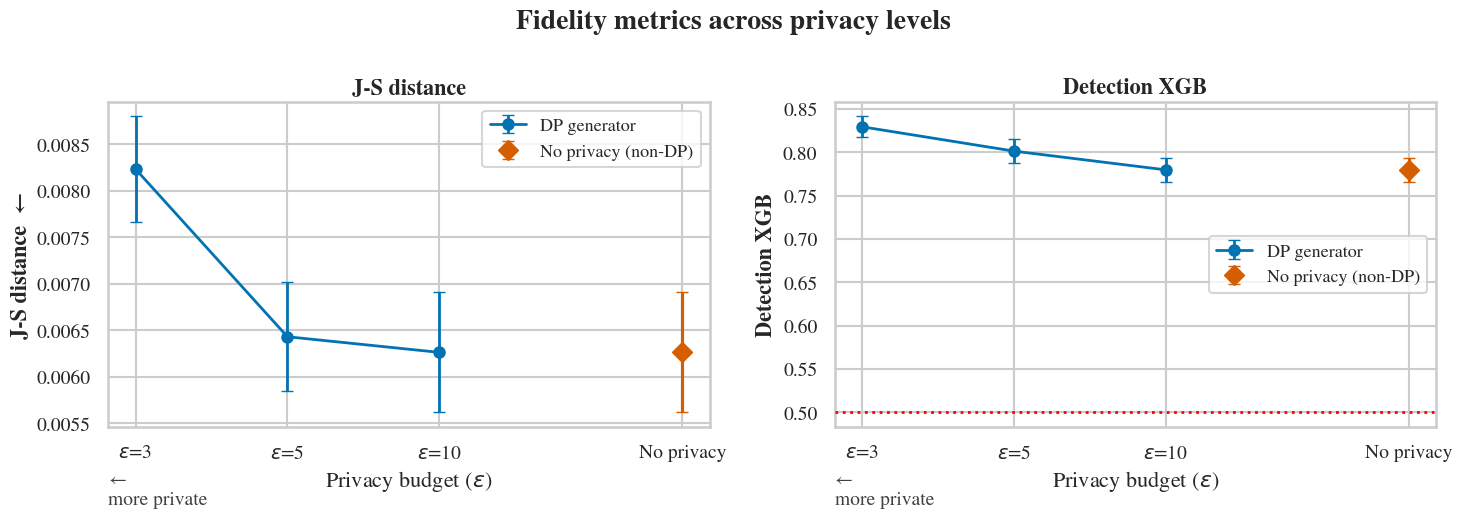

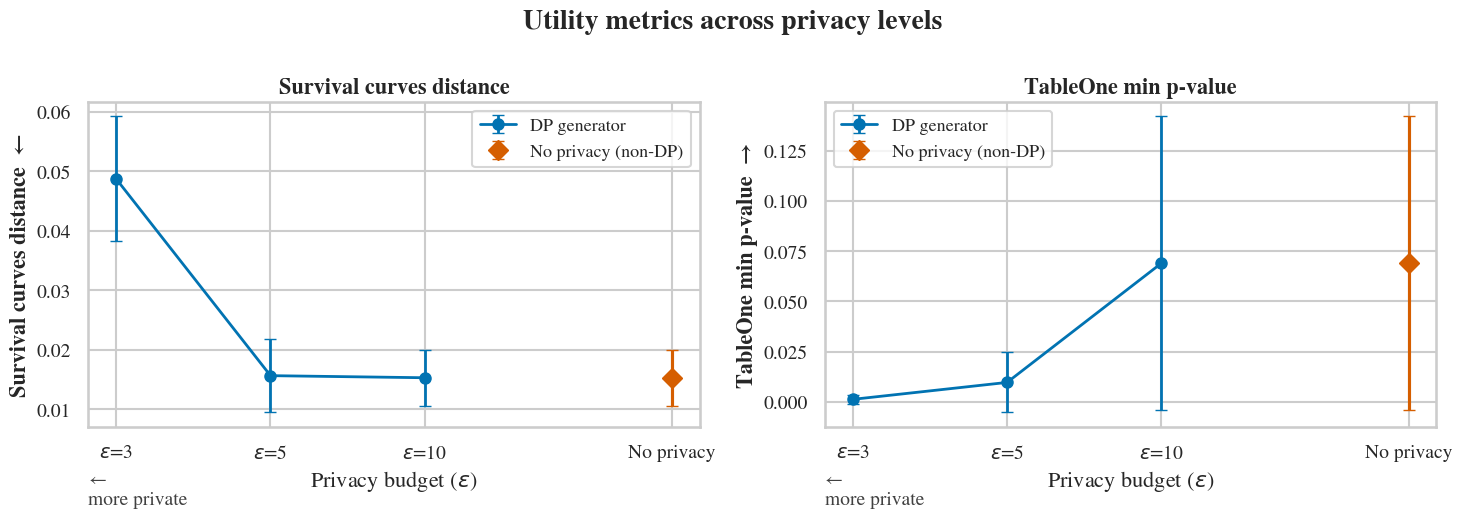

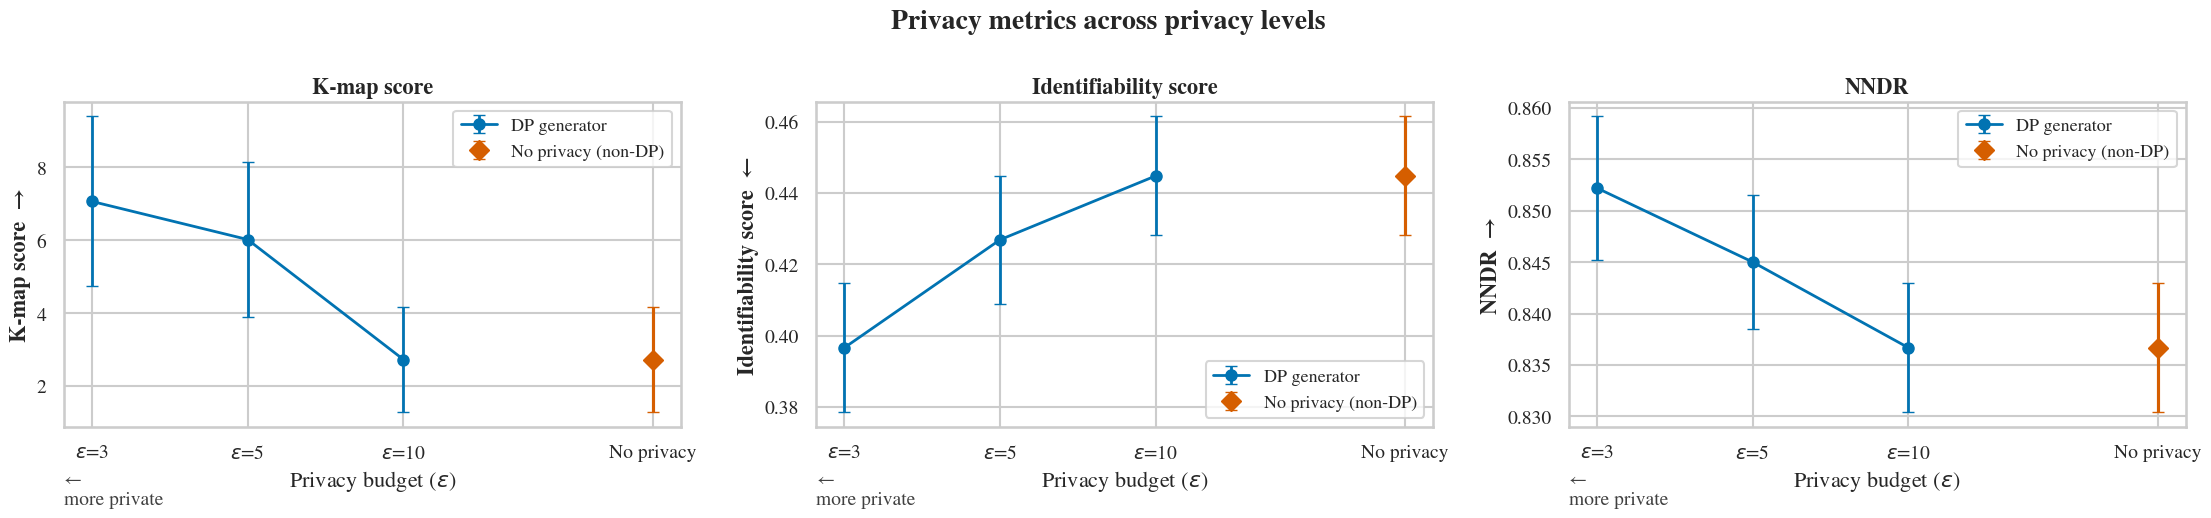

In [14]:
from visualization import visualize_perf_vs_privacy

dict_metrics_fidelity = {"Fidelity": [["J-S distance", "min"], ["Detection XGB", 0.5]]}
dict_metrics_utility = {"Utility": [["Survival curves distance", "min"], ["TableOne min p-value", "max"]]}
dict_metrics_privacy = {"Privacy": [["K-map score", "max"], ["Identifiability score", "min"], ["NNDR", "max"]]}

fig = visualize_perf_vs_privacy(score_df_complete, dict_metrics_fidelity, ncols=2,
                          suptitle="Fidelity metrics across privacy levels")
fig = visualize_perf_vs_privacy(score_df_complete, dict_metrics_utility, ncols=2,
                          suptitle="Utility metrics across privacy levels")
fig = visualize_perf_vs_privacy(score_df_complete, dict_metrics_privacy, ncols=3,
                          suptitle="Privacy metrics across privacy levels")

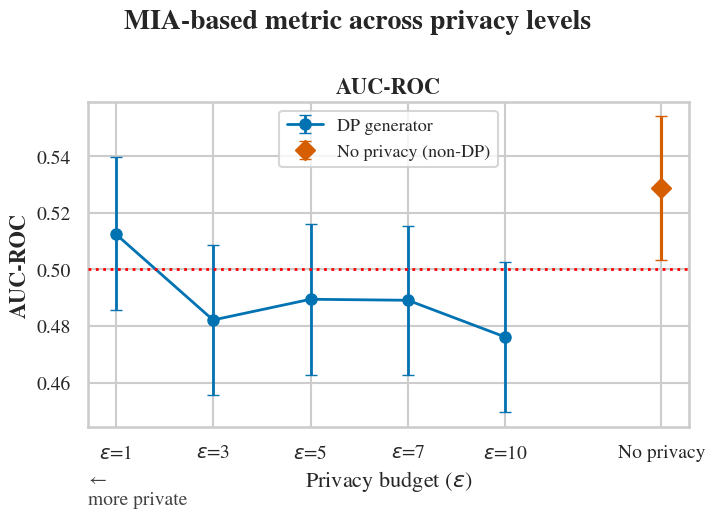

In [29]:
fig = visualize_perf_vs_privacy(mia_scores_df, {"Privacy": [["AUC-ROC", 0.5]]}, ncols=1,
                                suptitle="MIA-based metric across privacy levels")

Text(0, 0.5, 'Survival curves distance')

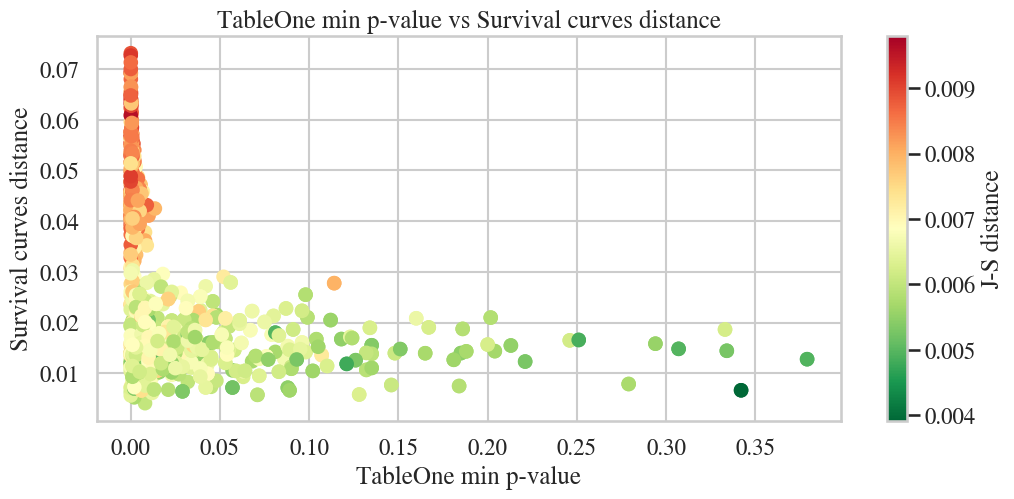

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(score_df_complete['TableOne min p-value'], score_df_complete['Survival curves distance'],
                c=score_df_complete['J-S distance'], cmap='RdYlGn_r')
fig.colorbar(sc, ax=ax, label='J-S distance')
ax.set_title('TableOne min p-value vs Survival curves distance')
ax.set_xlabel('TableOne min p-value')
ax.set_ylabel('Survival curves distance')